In [6]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_samples
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import os
os.getcwd()

'c:\\Users\\Bruno Abello\\Desktop\\Personal-projects\\Proyectos de Astronomía\\Laboratorio 4'

In [7]:
df = pd.read_csv("dataset_porcionado(in).csv").dropna(subset='pmra') # full gaia sample for one cluster
df = df.dropna(subset=['ra', 'dec', 'pmra','pmdec','parallax','bp_rp','phot_g_mean_mag'])
df.info(), df.columns

<class 'pandas.DataFrame'>
Index: 342356 entries, 0 to 365869
Data columns (total 29 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0.1               342356 non-null  int64  
 1   Unnamed: 0                 342356 non-null  int64  
 2   source_id                  342356 non-null  int64  
 3   ra                         342356 non-null  float64
 4   dec                        342356 non-null  float64
 5   parallax                   342356 non-null  float64
 6   pmra                       342356 non-null  float64
 7   pmdec                      342356 non-null  float64
 8   ruwe                       342356 non-null  float64
 9   phot_g_mean_mag            342356 non-null  float64
 10  bp_rp                      342356 non-null  float64
 11  radial_velocity            164635 non-null  float64
 12  ra_error                   342356 non-null  float64
 13  dec_error                  342356 non-null  f

(None,
 Index(['Unnamed: 0.1', 'Unnamed: 0', 'source_id', 'ra', 'dec', 'parallax',
        'pmra', 'pmdec', 'ruwe', 'phot_g_mean_mag', 'bp_rp', 'radial_velocity',
        'ra_error', 'dec_error', 'pmra_error', 'pmdec_error', 'parallax_error',
        'visibility_periods_used', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
        'nu_eff_used_in_astrometry', 'pseudocolour', 'ecl_lat',
        'astrometric_params_solved', 'zp', 'fidelity_v2', 'parallax_',
        'parallax_over_error', 'cell_id'],
       dtype='str'))

In [8]:

# features derivadas
df["dist_pc"] = 1000 / df["parallax"]
df["parallax_over_error"] = df["parallax_error"] / df["parallax"]

# filtro global (opcional pero recomendable)
df = df[df["parallax_over_error"] <= 0.1]

print("Total estrellas:", len(df))

Total estrellas: 342356


In [12]:
clustering_on = ['pmra','pmdec','dist_pc']

results = []

all_pmra_rel = []
all_pmdec_rel = []
all_sil = []

  0%|          | 0/64 [00:00<?, ?it/s]

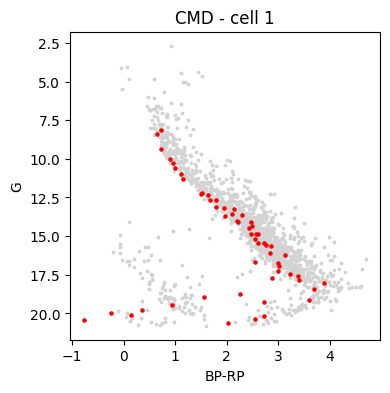

  2%|▏         | 1/64 [00:00<00:09,  6.43it/s]

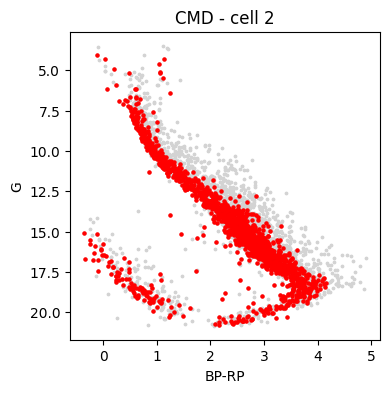

  3%|▎         | 2/64 [00:00<00:16,  3.74it/s]

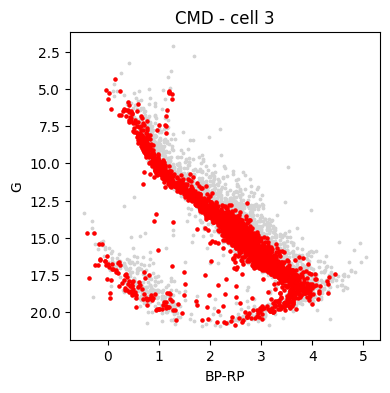

  5%|▍         | 3/64 [00:01<00:25,  2.36it/s]

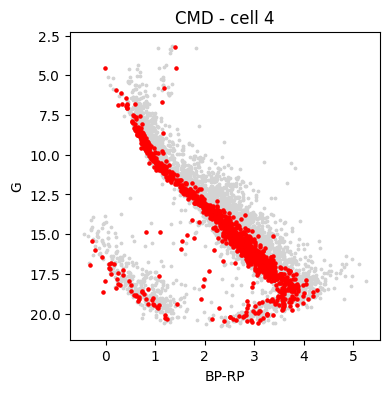

  6%|▋         | 4/64 [00:01<00:34,  1.75it/s]

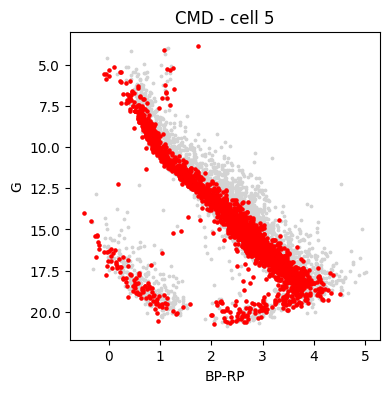

  8%|▊         | 5/64 [00:02<00:38,  1.55it/s]

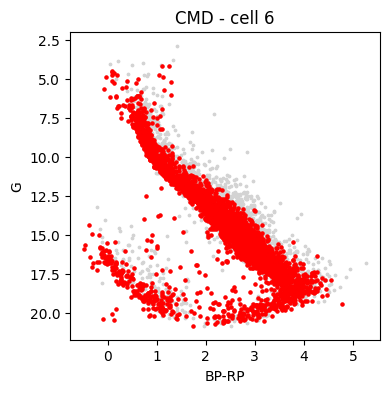

  9%|▉         | 6/64 [00:03<00:37,  1.53it/s]

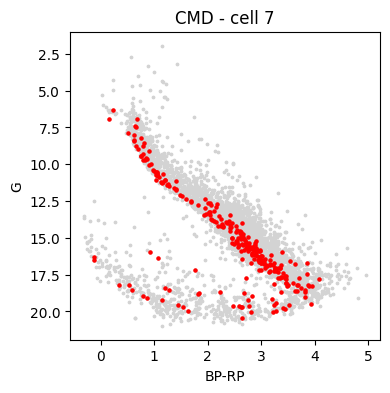

 11%|█         | 7/64 [00:03<00:33,  1.72it/s]

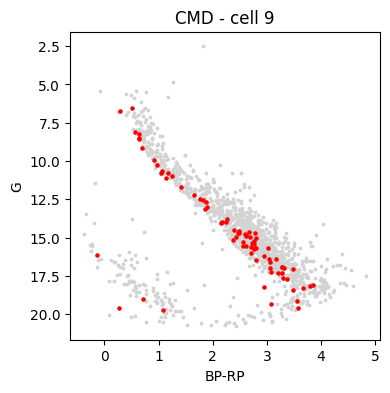

 14%|█▍        | 9/64 [00:03<00:18,  2.94it/s]

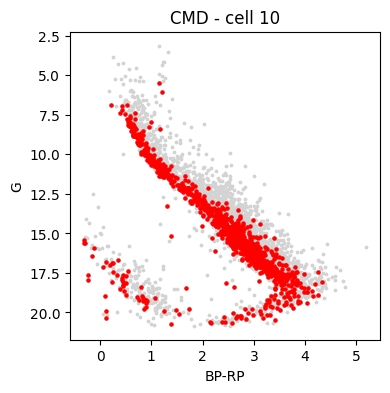

 16%|█▌        | 10/64 [00:04<00:18,  2.95it/s]

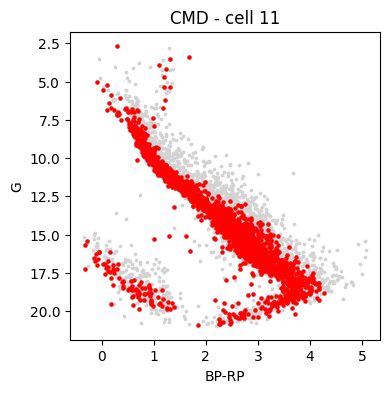

 17%|█▋        | 11/64 [00:04<00:22,  2.39it/s]

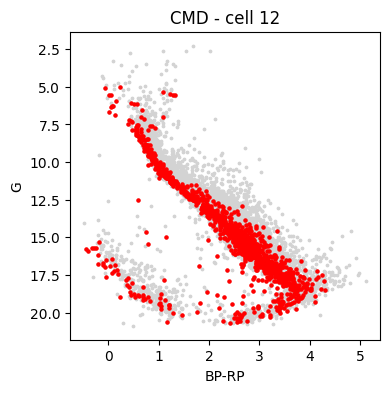

 19%|█▉        | 12/64 [00:05<00:28,  1.85it/s]

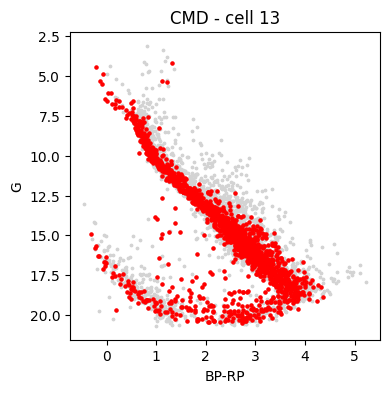

 20%|██        | 13/64 [00:06<00:28,  1.79it/s]

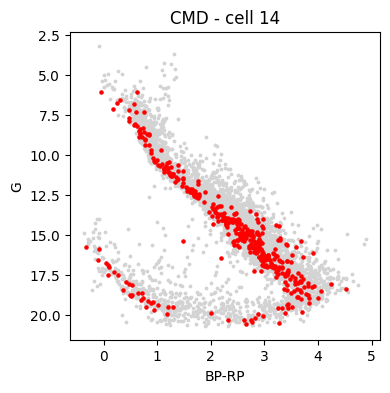

 22%|██▏       | 14/64 [00:06<00:28,  1.75it/s]

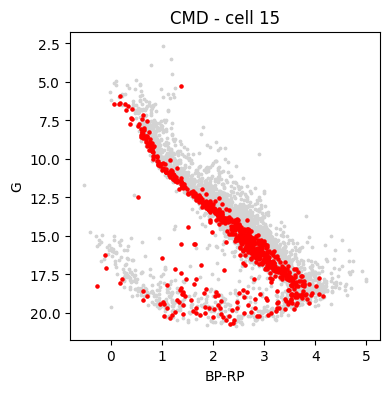

 23%|██▎       | 15/64 [00:07<00:25,  1.95it/s]

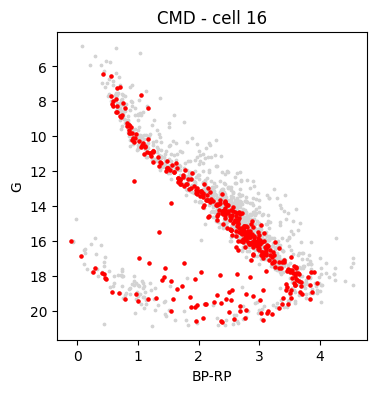

 25%|██▌       | 16/64 [00:07<00:19,  2.52it/s]

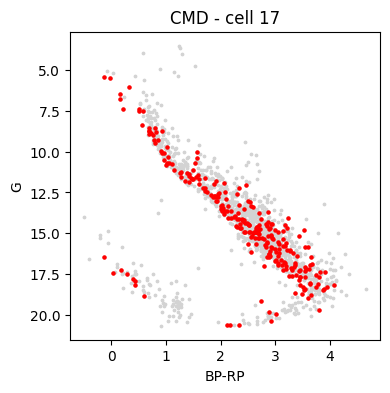

 27%|██▋       | 17/64 [00:07<00:14,  3.20it/s]

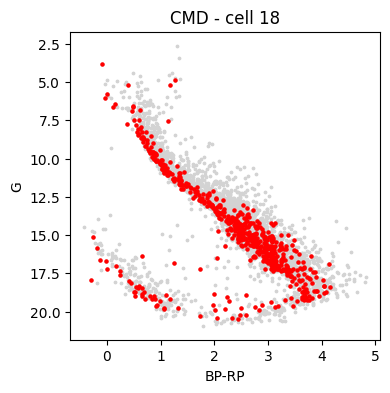

 28%|██▊       | 18/64 [00:07<00:14,  3.12it/s]

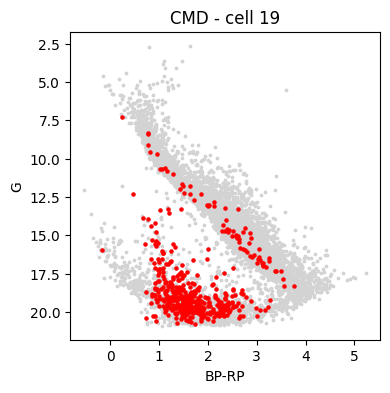

 30%|██▉       | 19/64 [00:08<00:21,  2.07it/s]

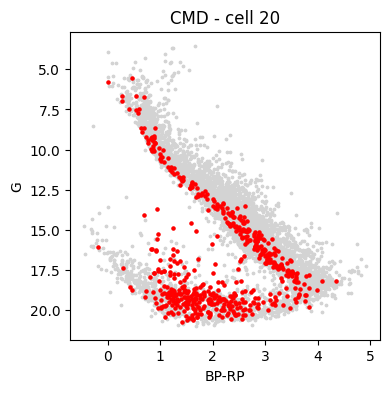

 31%|███▏      | 20/64 [00:09<00:27,  1.61it/s]

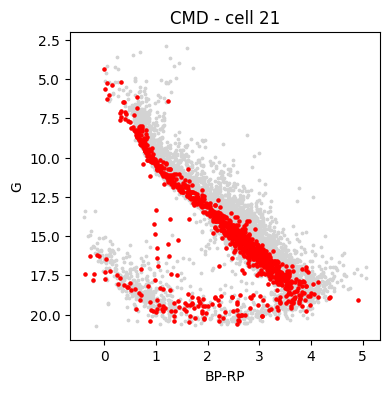

 33%|███▎      | 21/64 [00:10<00:29,  1.46it/s]

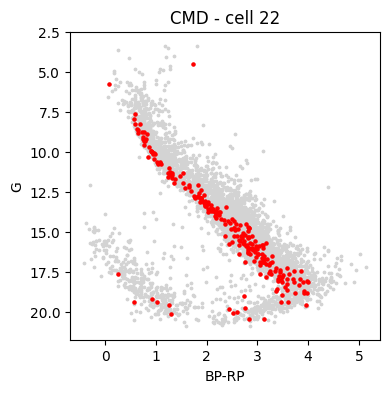

 34%|███▍      | 22/64 [00:11<00:27,  1.51it/s]

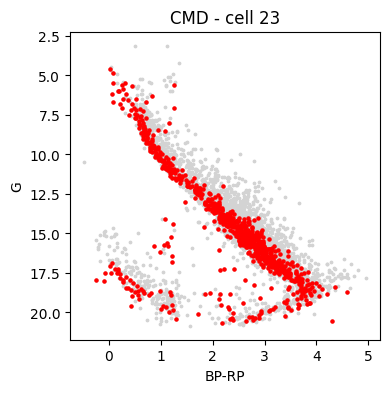

 36%|███▌      | 23/64 [00:11<00:23,  1.78it/s]

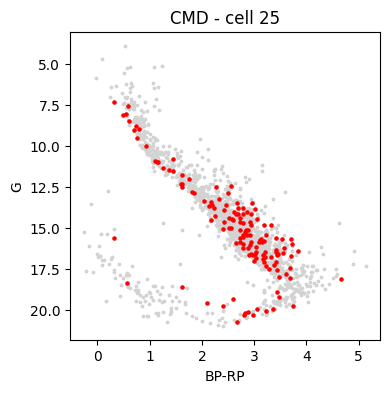

 39%|███▉      | 25/64 [00:11<00:12,  3.00it/s]

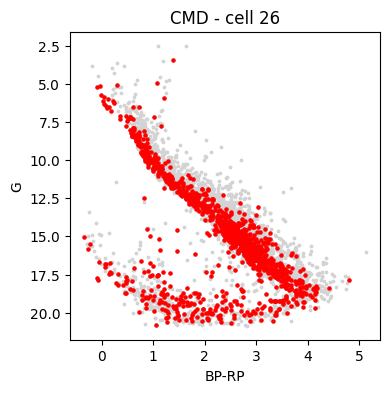

 41%|████      | 26/64 [00:11<00:12,  2.99it/s]

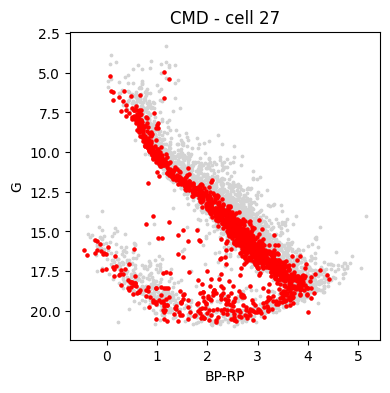

 42%|████▏     | 27/64 [00:12<00:15,  2.40it/s]

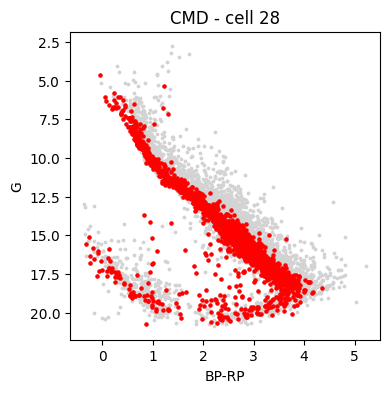

 44%|████▍     | 28/64 [00:13<00:18,  1.91it/s]

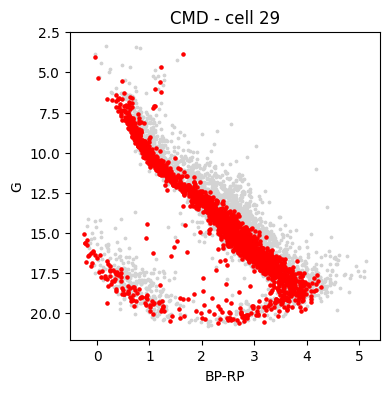

 45%|████▌     | 29/64 [00:14<00:19,  1.82it/s]

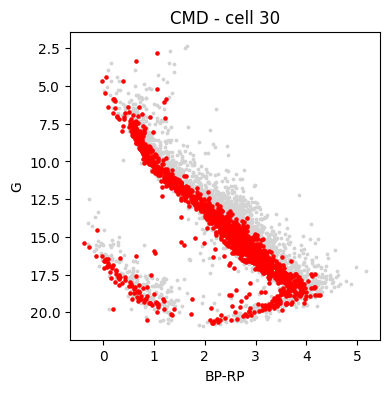

 47%|████▋     | 30/64 [00:14<00:17,  1.93it/s]

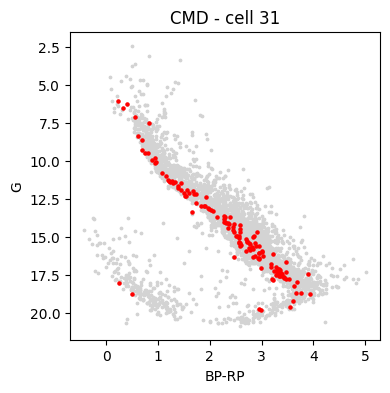

 48%|████▊     | 31/64 [00:14<00:15,  2.19it/s]

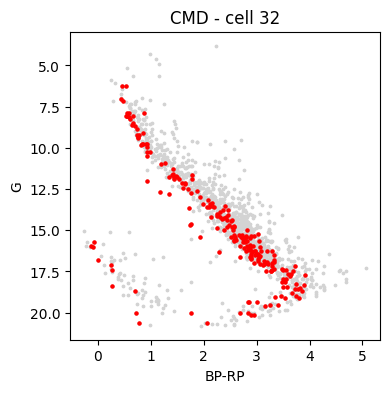

 50%|█████     | 32/64 [00:14<00:11,  2.82it/s]

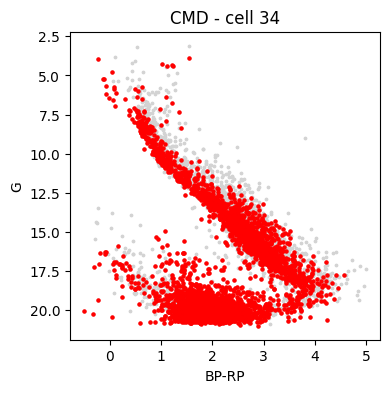

 53%|█████▎    | 34/64 [00:15<00:09,  3.02it/s]

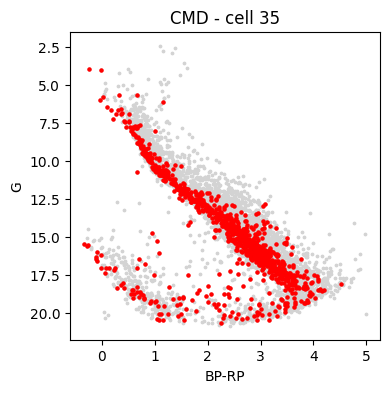

 55%|█████▍    | 35/64 [00:16<00:12,  2.38it/s]

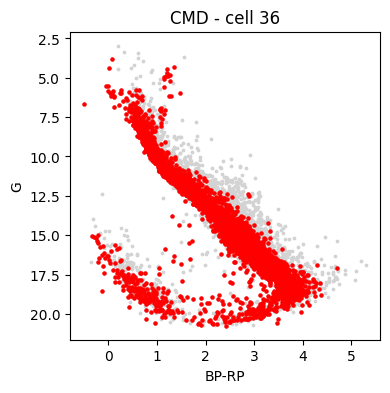

 56%|█████▋    | 36/64 [00:17<00:14,  1.92it/s]

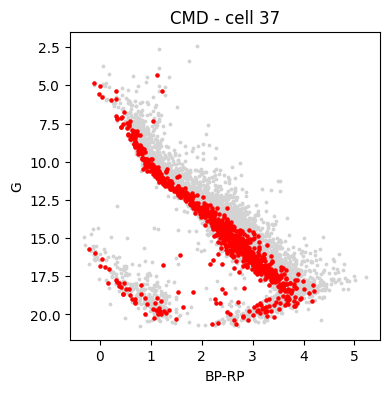

 58%|█████▊    | 37/64 [00:17<00:14,  1.88it/s]

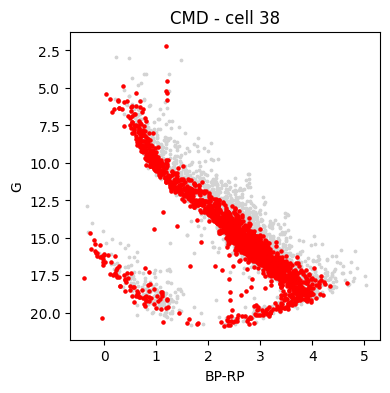

 59%|█████▉    | 38/64 [00:17<00:12,  2.05it/s]

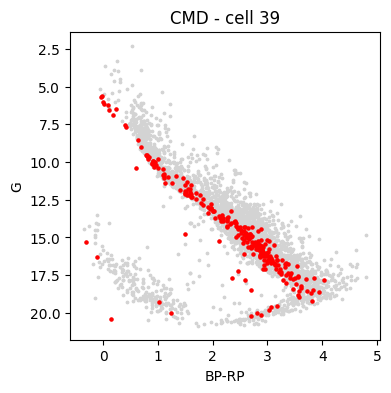

 61%|██████    | 39/64 [00:18<00:11,  2.25it/s]

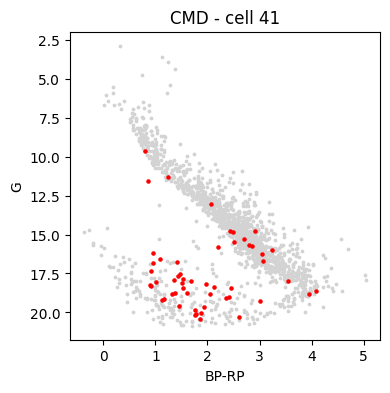

 64%|██████▍   | 41/64 [00:18<00:06,  3.62it/s]

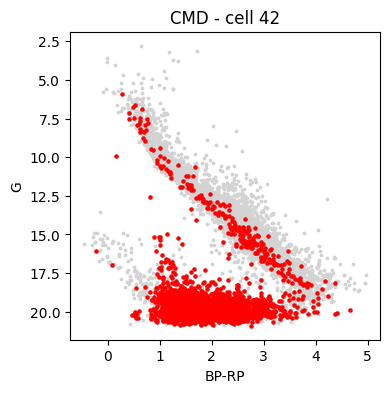

 66%|██████▌   | 42/64 [00:19<00:08,  2.62it/s]

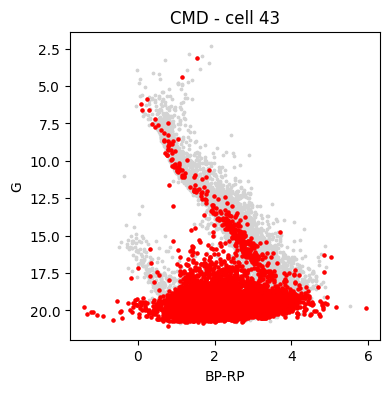

 67%|██████▋   | 43/64 [00:29<01:04,  3.07s/it]

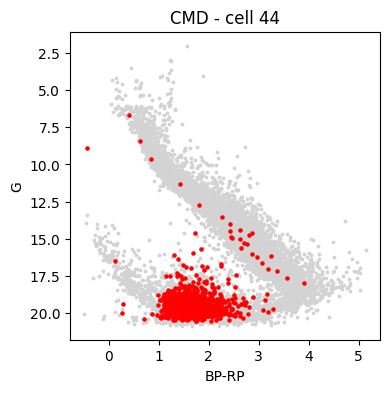

 69%|██████▉   | 44/64 [00:32<00:56,  2.83s/it]

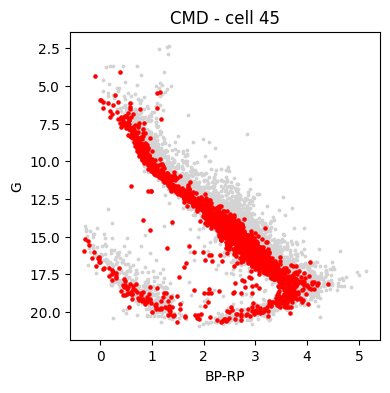

 70%|███████   | 45/64 [00:33<00:43,  2.29s/it]

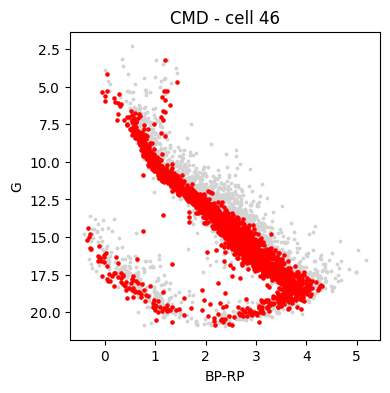

 72%|███████▏  | 46/64 [00:33<00:32,  1.83s/it]

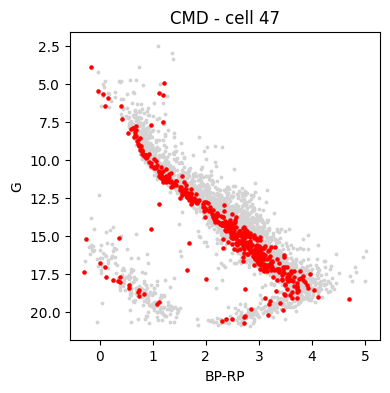

 73%|███████▎  | 47/64 [00:34<00:23,  1.40s/it]

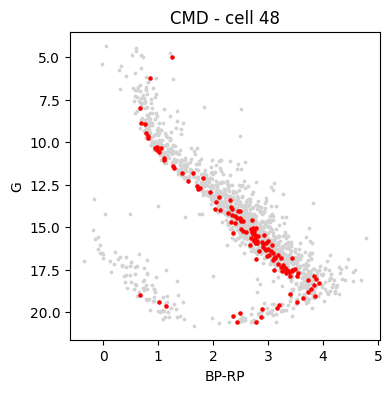

 75%|███████▌  | 48/64 [00:34<00:16,  1.03s/it]

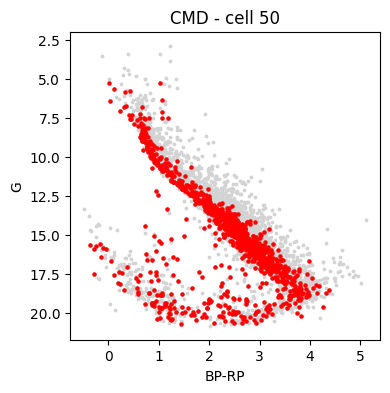

 78%|███████▊  | 50/64 [00:34<00:09,  1.50it/s]

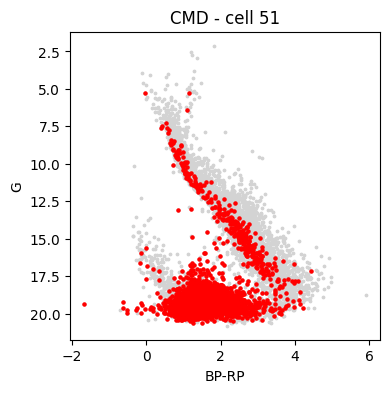

 80%|███████▉  | 51/64 [00:36<00:13,  1.06s/it]

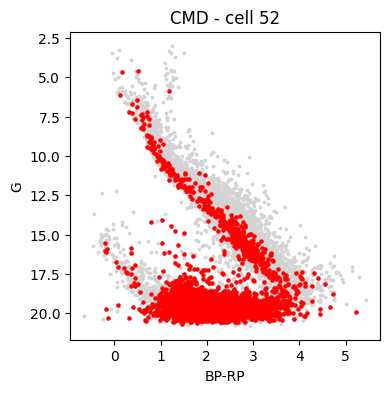

 81%|████████▏ | 52/64 [00:38<00:15,  1.33s/it]

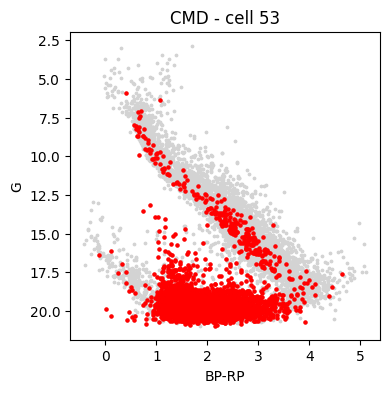

 83%|████████▎ | 53/64 [00:40<00:16,  1.48s/it]

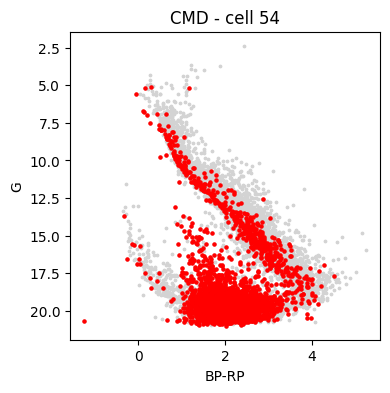

 84%|████████▍ | 54/64 [00:42<00:14,  1.46s/it]

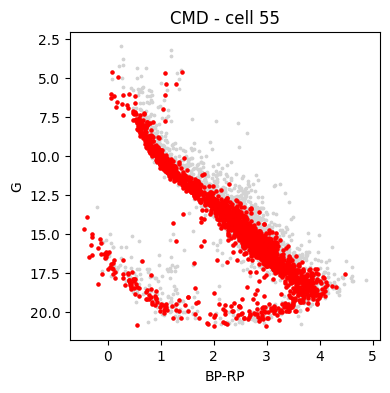

 86%|████████▌ | 55/64 [00:42<00:10,  1.14s/it]

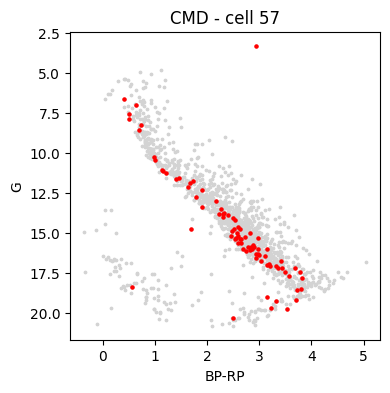

 89%|████████▉ | 57/64 [00:42<00:04,  1.51it/s]

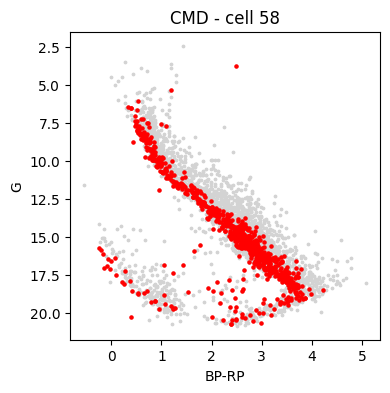

 91%|█████████ | 58/64 [00:43<00:03,  1.70it/s]

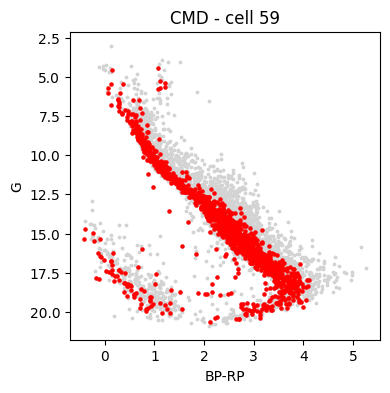

 92%|█████████▏| 59/64 [00:43<00:02,  1.67it/s]

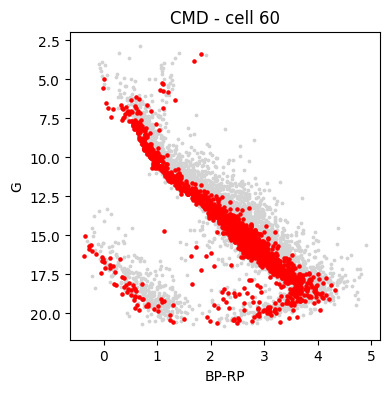

 94%|█████████▍| 60/64 [00:44<00:02,  1.51it/s]

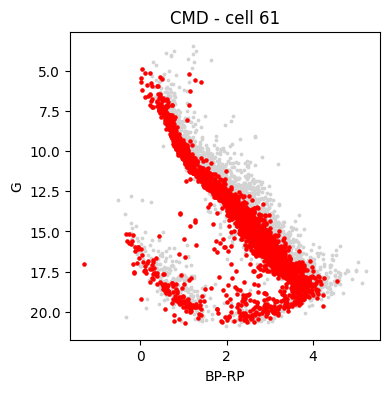

 95%|█████████▌| 61/64 [00:45<00:02,  1.42it/s]

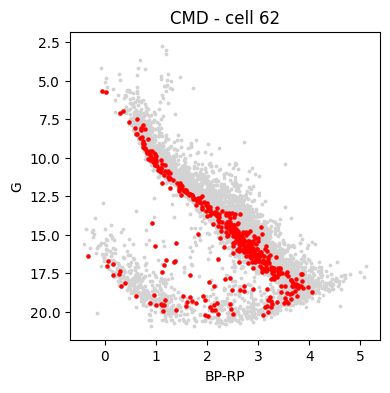

 97%|█████████▋| 62/64 [00:46<00:01,  1.41it/s]

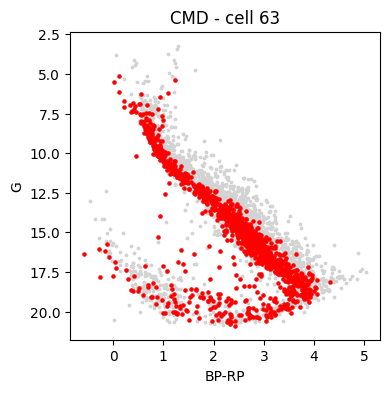

 98%|█████████▊| 63/64 [00:46<00:00,  1.63it/s]

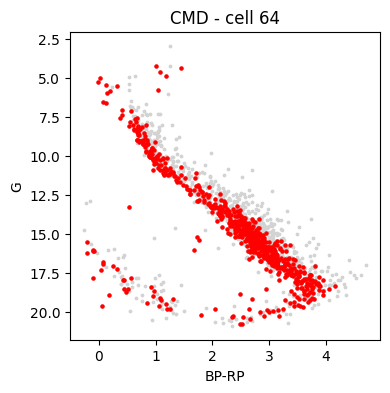

100%|██████████| 64/64 [00:46<00:00,  1.37it/s]


Proceso terminado.


In [ ]:
for cell_id in tqdm(sorted(df["cell_id"].unique())):

    df_cell = df[df["cell_id"] == cell_id].copy()

    if len(df_cell) < 50:
        continue

    # ------------------
    # preparar datos
    # ------------------

    features = df_cell[clustering_on]

    data_scaled = RobustScaler().fit_transform(features)

    # ------------------
    # HDBSCAN
    # ------------------

    hd = HDBSCAN(
        min_cluster_size=45,
        min_samples=5,
        metric='euclidean'
    ).fit(data_scaled)

    labels = hd.labels_

    df_cell["label_hb"] = labels

    # ------------------
    # silhouette
    # ------------------

    if len(set(labels)) > 1:
        sil = silhouette_samples(data_scaled, labels)
        df_cell["silhouette"] = sil
    else:
        df_cell["silhouette"] = np.nan

    # ------------------
    # centrar VPD
    # ------------------

    pmra_center = df_cell["pmra"].median()
    pmdec_center = df_cell["pmdec"].median()

    df_cell["pmra_rel"] = df_cell["pmra"] - pmra_center
    df_cell["pmdec_rel"] = df_cell["pmdec"] - pmdec_center

    # guardar para VPD global

    all_pmra_rel.append(df_cell["pmra_rel"])
    all_pmdec_rel.append(df_cell["pmdec_rel"])
    all_sil.append(df_cell["silhouette"])

    # ======================
    # FIGURA VPD + CMD
    # ======================

    fig, axes = plt.subplots(1,2, figsize=(12,5))

    # ----- VPD -----

    sc = axes[0].scatter(
        df_cell["pmra_rel"],
        df_cell["pmdec_rel"],
        c=df_cell["silhouette"],
        cmap="viridis",
        s=5
    )

    axes[0].set_xlabel("pmRA (centrado)")
    axes[0].set_ylabel("pmDEC (centrado)")
    axes[0].set_title(f"VPD - cell {cell_id}")

    # ----- CMD -----

    axes[1].scatter(
        df_cell["bp_rp"],
        df_cell["phot_g_mean_mag"],
        c=df_cell["silhouette"],
        cmap="viridis",
        s=5
    )

    axes[1].invert_yaxis()

    axes[1].set_xlabel("BP-RP")
    axes[1].set_ylabel("G")
    axes[1].set_title("CMD")

    fig.colorbar(sc, ax=axes, label="silhouette")

    plt.tight_layout()
    plt.show()

    results.append(df_cell)

df_final = pd.concat(results)

df_final.to_csv("clusters_64regiones.csv", index=False)


# ======================
# VPD GLOBAL
# ======================

pmra_all = pd.concat(all_pmra_rel)
pmdec_all = pd.concat(all_pmdec_rel)
sil_all = pd.concat(all_sil)

plt.figure(figsize=(8,8))

sc = plt.scatter(
    pmra_all,
    pmdec_all,
    c=sil_all,
    cmap="viridis",
    s=2
)

plt.xlabel("pmRA centrado")
plt.ylabel("pmDEC centrado")

plt.title("VPD global combinado")

plt.colorbar(sc, label="silhouette")

plt.show()